In [7]:
# Data Consolidation

In [8]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# 1. Grab all Premier League files
all_files = glob.glob("E0*.csv") 
if len(all_files) == 0:
    raise FileNotFoundError("No E0*.csv files found.")

df_list = [pd.read_csv(file, encoding='latin1', on_bad_lines='skip') for file in all_files]
master_df = pd.concat(df_list, axis=0, ignore_index=True)

# 2. Keep the important feature 
columns_to_keep = [
    'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 
    'HS', 'AS', 'HST', 'AST', 'HC', 'AC'
]
df_clean = master_df[[col for col in columns_to_keep if col in master_df.columns]].copy()

# 3. Standardize and sort chronological
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, format='mixed')
df_clean = df_clean.sort_values(by='Date').reset_index(drop=True)
df_clean = df_clean.dropna(subset=['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']).copy()

print(f"Rows: {len(df_clean)}")

Rows: 4091


In [9]:
# EWMA Feature Engineering

In [10]:
ALPHA = 0.1
team_ewma = {}

# Feature lists
h_scored, h_conceded, h_sot_for, h_sot_against = [], [], [], []
a_scored, a_conceded, a_sot_for, a_sot_against = [], [], [], []

def get_season(date):
    if date.month >= 7:
        return date.year
    else:
        return date.year - 1

def update_ewma(current_ewma, new_value):
    if pd.isna(current_ewma): return new_value
    return (ALPHA * new_value) + ((1 - ALPHA) * current_ewma)

for index, row in df_clean.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    current_season = get_season(row['Date'])

    # Initialise team state if first time seen
    if home not in team_ewma:
        team_ewma[home] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}
    if away not in team_ewma:
        team_ewma[away] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}

    if team_ewma[home]['last_season'] != current_season:
        team_ewma[home] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}
    if team_ewma[away]['last_season'] != current_season:
        team_ewma[away] = {'scored': np.nan, 'conceded': np.nan,
                           'sot_for': np.nan, 'sot_against': np.nan,
                           'last_season': current_season}

    # extract N-1 state 
    h_scored.append(team_ewma[home]['scored'])
    h_conceded.append(team_ewma[home]['conceded'])
    h_sot_for.append(team_ewma[home]['sot_for'])
    h_sot_against.append(team_ewma[home]['sot_against'])

    a_scored.append(team_ewma[away]['scored'])
    a_conceded.append(team_ewma[away]['conceded'])
    a_sot_for.append(team_ewma[away]['sot_for'])
    a_sot_against.append(team_ewma[away]['sot_against'])

    # update state w/ current match result
    team_ewma[home]['scored']      = update_ewma(team_ewma[home]['scored'], row['FTHG'])
    team_ewma[home]['conceded']    = update_ewma(team_ewma[home]['conceded'], row['FTAG'])
    team_ewma[home]['sot_for']     = update_ewma(team_ewma[home]['sot_for'], row['HST'])
    team_ewma[home]['sot_against'] = update_ewma(team_ewma[home]['sot_against'], row['AST'])

    team_ewma[away]['scored']      = update_ewma(team_ewma[away]['scored'], row['FTAG'])
    team_ewma[away]['conceded']    = update_ewma(team_ewma[away]['conceded'], row['FTHG'])
    team_ewma[away]['sot_for']     = update_ewma(team_ewma[away]['sot_for'], row['AST'])
    team_ewma[away]['sot_against'] = update_ewma(team_ewma[away]['sot_against'], row['HST'])

    # update season tracker
    team_ewma[home]['last_season'] = current_season
    team_ewma[away]['last_season'] = current_season

# Assign to df
df_clean['H_AvgScored'], df_clean['H_AvgConceded'] = h_scored, h_conceded
df_clean['H_AvgSOT'], df_clean['H_AvgSOT_Conceded'] = h_sot_for, h_sot_against
df_clean['A_AvgScored'], df_clean['A_AvgConceded'] = a_scored, a_conceded
df_clean['A_AvgSOT'], df_clean['A_AvgSOT_Conceded'] = a_sot_for, a_sot_against

# Drop only rows where EWMA features are NaN
ewma_feature_cols = [
    'H_AvgScored', 'H_AvgConceded', 'H_AvgSOT', 'H_AvgSOT_Conceded',
    'A_AvgScored', 'A_AvgConceded', 'A_AvgSOT', 'A_AvgSOT_Conceded'
]
df_model = df_clean.dropna(subset=ewma_feature_cols).reset_index(drop=True)

# TARGET-SPECIFIC FEATURES
# Goals matchup 
goals_diff_home = df_model['H_AvgScored'] - df_model['A_AvgConceded']
goals_diff_away = df_model['A_AvgScored'] - df_model['H_AvgConceded']
df_model['Net_Goal_Dominance'] = goals_diff_home - goals_diff_away

# SOT matchup
sot_diff_home = df_model['H_AvgSOT'] - df_model['A_AvgSOT_Conceded']
sot_diff_away = df_model['A_AvgSOT'] - df_model['H_AvgSOT_Conceded']
df_model['Net_SOT_Dominance'] = sot_diff_home - sot_diff_away

# Aggregate intensity features
df_model['Total_Attacking_Intensity'] = df_model['H_AvgSOT'] + df_model['A_AvgSOT']
df_model['Total_Defensive_Fragility'] = df_model['H_AvgSOT_Conceded'] + df_model['A_AvgSOT_Conceded']

In [11]:
df_h2h_source = df_clean.sort_values('Date').copy()

h2h_records = {}  

h2h_home_winrate = []

for _, row in df_h2h_source.iterrows():
    home = row['HomeTeam']
    away = row['AwayTeam']
    key = (home, away)

    # Extract PAST record before this match
    if key not in h2h_records:
        h2h_records[key] = {'home_wins': 0, 'total': 0}

    past = h2h_records[key]

    if past['total'] == 0:
        h2h_home_winrate.append(np.nan)
    else:
        h2h_home_winrate.append(past['home_wins'] / past['total'])

    past['total'] += 1
    if row['FTR'] == 'H':
        past['home_wins'] += 1

df_h2h_source['H2H_HomeWinRate'] = h2h_home_winrate

df_model = df_model.merge(
    df_h2h_source[['Date', 'HomeTeam', 'AwayTeam', 'H2H_HomeWinRate']],
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

overall_home_winrate = (df_clean['FTR'] == 'H').mean()
df_model['H2H_HomeWinRate'] = df_model['H2H_HomeWinRate'].fillna(overall_home_winrate)

In [12]:
# ALPHA Sensitivity Analysis

  ALPHA=0.10 (19-game window) → Mean CV Log-Loss: 1.0595
  ALPHA=0.20 (9-game window) → Mean CV Log-Loss: 1.0627
  ALPHA=0.33 (5-game window) → Mean CV Log-Loss: 1.0659
  ALPHA=0.50 (3-game window) → Mean CV Log-Loss: 1.0674


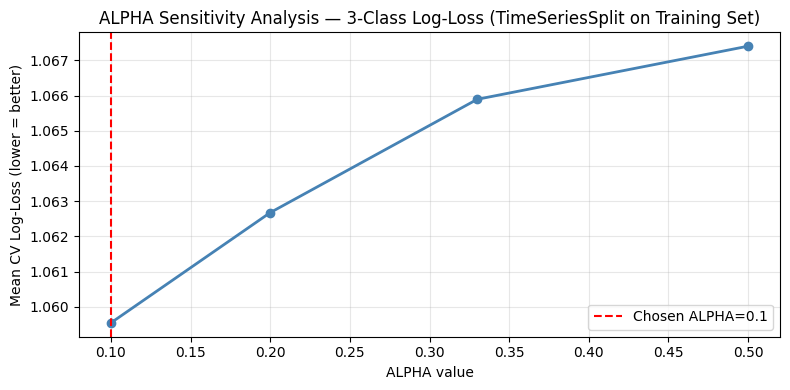


Best ALPHA from 3-class CV: 0.1


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

def build_ewma_features(df, alpha):
    team_ewma = {}
    h_scored, h_conceded, h_sot_for, h_sot_against = [], [], [], []
    a_scored, a_conceded, a_sot_for, a_sot_against = [], [], [], []

    def get_season(date):
        return date.year if date.month >= 7 else date.year - 1

    def update_ewma(current, new):
        if pd.isna(current): return new
        return (alpha * new) + ((1 - alpha) * current)

    for _, row in df.iterrows():
        home, away = row['HomeTeam'], row['AwayTeam']
        current_season = get_season(row['Date'])

        for team in [home, away]:
            if team not in team_ewma:
                team_ewma[team] = {'scored': np.nan, 'conceded': np.nan,
                                   'sot_for': np.nan, 'sot_against': np.nan,
                                   'last_season': current_season}
            if team_ewma[team]['last_season'] != current_season:
                team_ewma[team] = {'scored': np.nan, 'conceded': np.nan,
                                   'sot_for': np.nan, 'sot_against': np.nan,
                                   'last_season': current_season}

        h_scored.append(team_ewma[home]['scored'])
        h_conceded.append(team_ewma[home]['conceded'])
        h_sot_for.append(team_ewma[home]['sot_for'])
        h_sot_against.append(team_ewma[home]['sot_against'])
        a_scored.append(team_ewma[away]['scored'])
        a_conceded.append(team_ewma[away]['conceded'])
        a_sot_for.append(team_ewma[away]['sot_for'])
        a_sot_against.append(team_ewma[away]['sot_against'])

        team_ewma[home]['scored']      = update_ewma(team_ewma[home]['scored'], row['FTHG'])
        team_ewma[home]['conceded']    = update_ewma(team_ewma[home]['conceded'], row['FTAG'])
        team_ewma[home]['sot_for']     = update_ewma(team_ewma[home]['sot_for'], row['HST'])
        team_ewma[home]['sot_against'] = update_ewma(team_ewma[home]['sot_against'], row['AST'])
        team_ewma[away]['scored']      = update_ewma(team_ewma[away]['scored'], row['FTAG'])
        team_ewma[away]['conceded']    = update_ewma(team_ewma[away]['conceded'], row['FTHG'])
        team_ewma[away]['sot_for']     = update_ewma(team_ewma[away]['sot_for'], row['AST'])
        team_ewma[away]['sot_against'] = update_ewma(team_ewma[away]['sot_against'], row['HST'])
        team_ewma[home]['last_season'] = current_season
        team_ewma[away]['last_season'] = current_season

    result = df.copy()
    result['H_AvgScored'], result['H_AvgConceded'] = h_scored, h_conceded
    result['H_AvgSOT'],    result['H_AvgSOT_Conceded'] = h_sot_for, h_sot_against
    result['A_AvgScored'], result['A_AvgConceded'] = a_scored, a_conceded
    result['A_AvgSOT'],    result['A_AvgSOT_Conceded'] = a_sot_for, a_sot_against

    ewma_cols = ['H_AvgScored','H_AvgConceded','H_AvgSOT','H_AvgSOT_Conceded',
                 'A_AvgScored','A_AvgConceded','A_AvgSOT','A_AvgSOT_Conceded']
    result = result.dropna(subset=ewma_cols).reset_index(drop=True)

    goals_diff_home = result['H_AvgScored'] - result['A_AvgConceded']
    goals_diff_away = result['A_AvgScored'] - result['H_AvgConceded']
    result['Net_Goal_Dominance'] = goals_diff_home - goals_diff_away

    sot_diff_home = result['H_AvgSOT'] - result['A_AvgSOT_Conceded']
    sot_diff_away = result['A_AvgSOT'] - result['H_AvgSOT_Conceded']
    result['Net_SOT_Dominance'] = sot_diff_home - sot_diff_away
    result['Total_Attacking_Intensity'] = result['H_AvgSOT'] + result['A_AvgSOT']
    result['Total_Defensive_Fragility'] = result['H_AvgSOT_Conceded'] + result['A_AvgSOT_Conceded']
    return result

# Candidate ALPHA values
# ALPHA = 2/(N+1)
alpha_candidates = [0.10, 0.20, 0.33, 0.50]
features_for_cv = [
    'Net_Goal_Dominance',
    'Net_SOT_Dominance',
    'Total_Attacking_Intensity',
    'Total_Defensive_Fragility'
]

split_index_clean = int(len(df_clean) * 0.8)
df_train_clean = df_clean.iloc[:split_index_clean].copy()

tscv = TimeSeriesSplit(n_splits=5)
alpha_results = {}

le_cv = LabelEncoder()

for alpha in alpha_candidates:
    df_alpha = build_ewma_features(df_train_clean, alpha)
    X = df_alpha[features_for_cv].values

    y = le_cv.fit_transform(df_alpha['FTR'])

    fold_scores = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        sc = StandardScaler()
        X_tr  = sc.fit_transform(X_tr)
        X_val = sc.transform(X_val)

        clf = LogisticRegression(
            multi_class='multinomial',
            max_iter=1000,
            random_state=42
        )
        clf.fit(X_tr, y_tr)
        y_val_proba = clf.predict_proba(X_val)

        fold_scores.append(-log_loss(y_val, y_val_proba))

    alpha_results[alpha] = np.mean(fold_scores)
    equiv_n = round((2 / alpha) - 1)
    print(f"  ALPHA={alpha:.2f} ({equiv_n}-game window) → Mean CV Log-Loss: {-np.mean(fold_scores):.4f}")

# Plot
plt.figure(figsize=(8, 4))
plot_values = [-v for v in alpha_results.values()]
plt.plot(list(alpha_results.keys()), plot_values,
         marker='o', linewidth=2, color='steelblue')
plt.axvline(x=ALPHA, color='red', linestyle='--', label=f'Chosen ALPHA={ALPHA}')
plt.xlabel('ALPHA value')
plt.ylabel('Mean CV Log-Loss (lower = better)')
plt.title('ALPHA Sensitivity Analysis — 3-Class Log-Loss (TimeSeriesSplit on Training Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = min(alpha_results, key=lambda a: -alpha_results[a]) 
print(f"\nBest ALPHA from 3-class CV: {best_alpha}")

In [15]:
# Elo Integration & Target Engineering

In [16]:
import time
from sklearn.preprocessing import LabelEncoder, StandardScaler

elo_map = {
    'Arsenal': 'Arsenal', 
    'Aston Villa': 'Aston Villa',        
    'Bournemouth': 'Bournemouth',
    'Brentford': 'Brentford', 
    'Brighton': 'Brighton', 
    'Burnley': 'Burnley',
    'Cardiff': 'Cardiff', 
    'Chelsea': 'Chelsea', 
    'Crystal Palace': 'Crystal Palace',  
    'Everton': 'Everton', 
    'Fulham': 'Fulham', 
    'Huddersfield': 'Huddersfield',
    'Hull': 'Hull', 
    'Ipswich': 'Ipswich', 
    'Leeds': 'Leeds', 
    'Leicester': 'Leicester',
    'Liverpool': 'Liverpool', 
    'Luton': 'Luton', 
    'Man City': 'Man City',              
    'Man United': 'Man United',          
    'Middlesbrough': 'Middlesbrough', 
    'Newcastle': 'Newcastle',
    'Norwich': 'Norwich', 
    "Nott'm Forest": 'Forest', 
    'QPR': 'QPR',
    'Sheff United': 'Sheffield United',  
    'Sheffield United': 'Sheffield United',
    'Southampton': 'Southampton', 
    'Spurs': 'Tottenham', 
    'Stoke': 'Stoke', 
    'Sunderland': 'Sunderland', 
    'Swansea': 'Swansea', 
    'Watford': 'Watford', 
    'West Brom': 'West Brom',            
    'West Ham': 'West Ham',              
    'Wolves': 'Wolves'
}

df_model['Home_Elo_Name'] = df_model['HomeTeam'].map(elo_map).fillna(df_model['HomeTeam'])
df_model['Away_Elo_Name'] = df_model['AwayTeam'].map(elo_map).fillna(df_model['AwayTeam'])
unique_teams = pd.concat([df_model['Home_Elo_Name'], df_model['Away_Elo_Name']]).unique()

elo_df_list = []
for team in unique_teams:
    try:
        clean_team = str(team).replace(" ", "")
        url = f"http://api.clubelo.com/{clean_team}"
        team_elo = pd.read_csv(url)[['Club', 'From', 'Elo']]
        elo_df_list.append(team_elo)
        time.sleep(0.2)
    except Exception as e:
        print(f"Warning: Could not fetch Elo for {team}.")

all_elo_df = pd.concat(elo_df_list, ignore_index=True)
all_elo_df['From'] = pd.to_datetime(all_elo_df['From'])
all_elo_df = all_elo_df.sort_values('From')

df_model = pd.merge_asof(df_model, all_elo_df.rename(columns={'Elo': 'Home_Elo', 'Club': 'Home_Club'}),
                         left_on='Date', right_on='From', left_by='Home_Elo_Name', right_by='Home_Club', direction='backward')
df_model = pd.merge_asof(df_model, all_elo_df.rename(columns={'Elo': 'Away_Elo', 'Club': 'Away_Club'}),
                         left_on='Date', right_on='From', left_by='Away_Elo_Name', right_by='Away_Club', direction='backward')

df_model['Elo_Diff'] = df_model['Home_Elo'] - df_model['Away_Elo']
df_model = df_model.dropna(subset=['Home_Elo', 'Away_Elo']).reset_index(drop=True)

df_model['Total_Goals'] = df_model['FTHG'] + df_model['FTAG']
df_model['Target_OU'] = (df_model['Total_Goals'] > 2.5).astype(int)

le = LabelEncoder()
df_model['Target_1X2'] = le.fit_transform(df_model['FTR'])  

features = [
    'Net_Goal_Dominance',
    'Net_SOT_Dominance',
    'Total_Attacking_Intensity',
    'Total_Defensive_Fragility',
    'Elo_Diff',
    'H2H_HomeWinRate',  
]

In [21]:
# Exploratory Data Analysis 

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# colors
navy_blue = "#122345"   
muted_teal = "#48918d"  
dark_maroon = "#7d1844" 
dusty_mauve = "#d8c8d3" 

palette_hda = {'H': navy_blue, 'D': muted_teal, 'A': dark_maroon}
palette_ou = ['#607c8e', '#6b4c65']

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

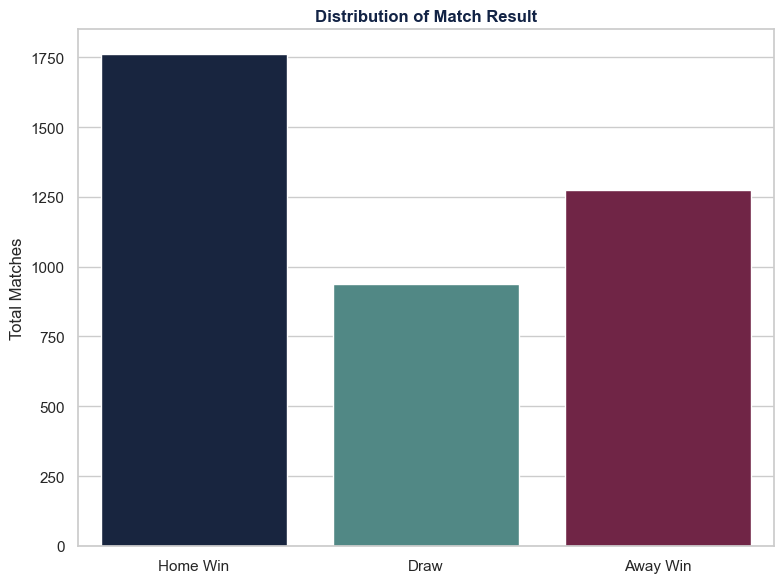

In [23]:
# Match Result Distribution
plt.figure(figsize=(8, 6))
ax1 = sns.countplot(data=df_model, x='FTR', order=['H', 'D', 'A'], palette=palette_hda)
ax1.set_title('Distribution of Match Result', color=navy_blue, fontweight='bold')
ax1.set_xlabel('')  
ax1.set_ylabel('Total Matches')
ax1.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax1.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot1_match_results.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show() 

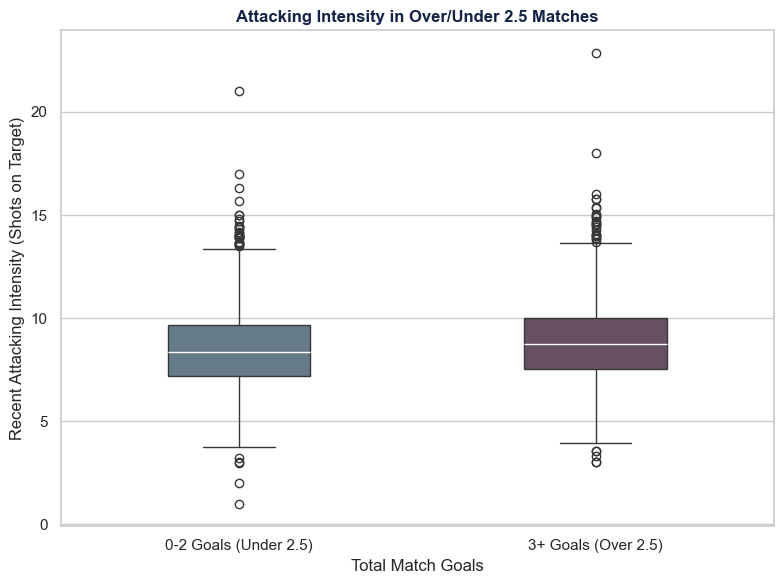

In [24]:
# Attacking Intensity vs Over/Under
plt.figure(figsize=(8, 6))
ax2 = sns.boxplot(data=df_model, x='Target_OU', y='Total_Attacking_Intensity', 
                  palette=palette_ou, width=0.4,
                  medianprops={'color': 'white', 'linewidth': 1})
ax2.set_title('Attacking Intensity in Over/Under 2.5 Matches', color=navy_blue, fontweight='bold')
ax2.set_xlabel('Total Match Goals')
ax2.set_ylabel('Recent Attacking Intensity (Shots on Target)')
ax2.set_xticklabels(['0-2 Goals (Under 2.5)', '3+ Goals (Over 2.5)'])
ax2.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot2_attacking_intensity.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

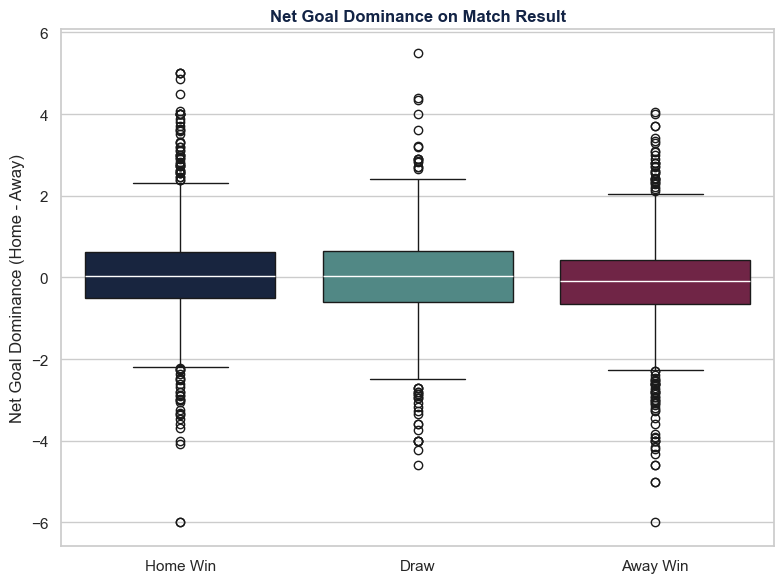

In [25]:
# Net Goal Dominance vs Result
plt.figure(figsize=(8, 6))
ax3 = sns.boxplot(data=df_model, x='FTR', y='Net_Goal_Dominance', order=['H', 'D', 'A'], 
                  palette=palette_hda, medianprops={'color': 'white', 'linewidth': 1})
ax3.set_title('Net Goal Dominance on Match Result', color=navy_blue, fontweight='bold')
ax3.set_xlabel('')  
ax3.set_ylabel('Net Goal Dominance (Home - Away)')
ax3.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax3.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot3_goal_dominance.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()


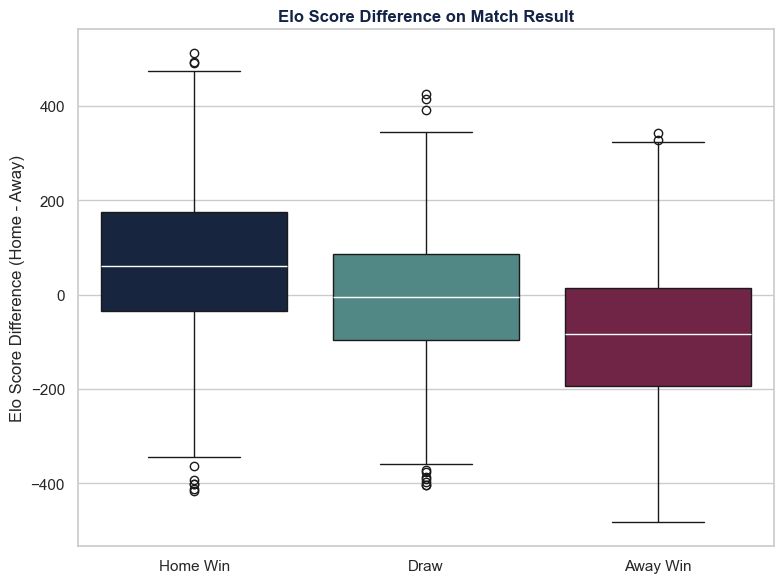

In [26]:
# Elo Differential vs Result
plt.figure(figsize=(8, 6))
ax4 = sns.boxplot(data=df_model, x='FTR', y='Elo_Diff', order=['H', 'D', 'A'], 
                  palette=palette_hda, medianprops={'color': 'white', 'linewidth': 1})
ax4.set_title('Elo Score Difference on Match Result', color=navy_blue, fontweight='bold')
ax4.set_xlabel('')  
ax4.set_ylabel('Elo Score Difference (Home - Away)')
ax4.set_xticklabels(['Home Win', 'Draw', 'Away Win'])
ax4.grid(False, axis='x')

plt.tight_layout()
plt.savefig('plot4_elo_difference.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()


In [28]:
# Train/Test Split & Standardisation

In [29]:
# 80/20 Split
split_index = int(len(df_model) * 0.8)
df_train = df_model.iloc[:split_index].copy()
df_test = df_model.iloc[split_index:].copy()

X_train, X_test = df_train[features], df_test[features]
y_ou_train, y_ou_test = df_train['Target_OU'], df_test['Target_OU']
y_1x2_train, y_1x2_test = df_train['Target_1X2'], df_test['Target_1X2']

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")

Train size: 3179, Test size: 795


In [14]:
# Correlation Analysis 

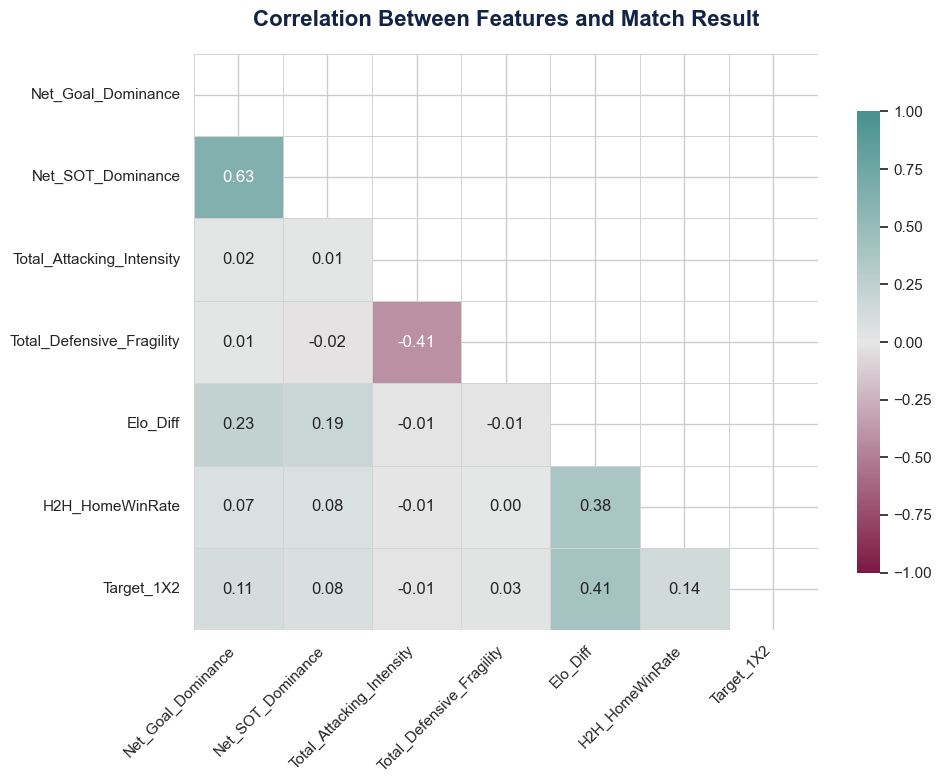

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

navy_blue = "#122345"   
muted_teal = "#48918d"  
dark_maroon = "#7d1844" 

light_grey = "#e6e6e6"

poster_cmap = mcolors.LinearSegmentedColormap.from_list("poster_diverging", [dark_maroon, light_grey, muted_teal])

plt.figure(figsize=(10, 8))
corr_matrix = df_train[features + ['Target_1X2']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=poster_cmap, 
            fmt=".2f", vmin=-1, vmax=1, linewidths=0.5, linecolor='lightgrey', 
            cbar_kws={"shrink": .8}) 

plt.title('Correlation Between Features and Match Result', 
          color=navy_blue, fontsize=16, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig('plot5_correlation_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()

In [31]:
# Model Training & Evaluation

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SVMSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # ← new import

ou_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
ou_model.fit(X_train_scaled, y_ou_train)
y_ou_pred = ou_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_ou_test, y_ou_pred):.3f}")
print(f"F1-Score: {f1_score(y_ou_test, y_ou_pred, average='weighted'):.3f}")
print(classification_report(y_ou_test, y_ou_pred, target_names=['Under 2.5', 'Over 2.5']))

base_fnn = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    max_iter=500, random_state=42, early_stopping=True
)

fnn_pipeline = ImbPipeline([
    ('smote', SVMSMOTE(random_state=42)),
    ('classifier', base_fnn)
])

calibrated_fnn = CalibratedClassifierCV(estimator=fnn_pipeline, method='sigmoid', cv=5)
calibrated_fnn.fit(X_train_scaled, y_1x2_train)  

y_1x2_pred_fnn = calibrated_fnn.predict(X_test_scaled)
y_1x2_proba_fnn = calibrated_fnn.predict_proba(X_test_scaled)

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                         eval_metric='mlogloss', random_state=42, n_jobs=-1)

voting_clf = VotingClassifier(estimators=[('rf', rf_clf), ('xgb', xgb_clf)], voting='soft')

ensemble_pipeline = ImbPipeline([
    ('smote', SVMSMOTE(random_state=42)),
    ('classifier', voting_clf)
])

calibrated_ensemble = CalibratedClassifierCV(estimator=ensemble_pipeline, method='sigmoid', cv=5)
calibrated_ensemble.fit(X_train_scaled, y_1x2_train)  

y_1x2_pred_ens = calibrated_ensemble.predict(X_test_scaled)
y_1x2_proba_ens = calibrated_ensemble.predict_proba(X_test_scaled)

#(RPS)
def calculate_rps(y_true, y_pred_proba):
    n_samples = len(y_true)
    rps_sum = 0
    for i in range(n_samples):
        obs = np.zeros(3)
        obs[y_true.iloc[i]] = 1
        cum_obs = np.cumsum(obs)
        cum_pred = np.cumsum(y_pred_proba[i])
        rps_sum += np.sum((cum_pred[:2] - cum_obs[:2])**2) / 2.0
    return rps_sum / n_samples

rps_score_fnn = calculate_rps(y_1x2_test, y_1x2_proba_fnn)
rps_score_ens = calculate_rps(y_1x2_test, y_1x2_proba_ens)

print(f"FNN RPS SCORE: {rps_score_fnn:.4f}")
print(f"VOTING ENSEMBLE RPS SCORE: {rps_score_ens:.4f}")

Accuracy: 0.536
F1-Score: 0.537
              precision    recall  f1-score   support

   Under 2.5       0.46      0.47      0.46       338
    Over 2.5       0.60      0.58      0.59       457

    accuracy                           0.54       795
   macro avg       0.53      0.53      0.53       795
weighted avg       0.54      0.54      0.54       795

FNN RPS SCORE: 0.2046
VOTING ENSEMBLE RPS SCORE: 0.2075


In [34]:
# O/U Model Baseline Comparison

In [37]:
from sklearn.metrics import brier_score_loss

# BASELINE COMPARISON & BRIER SCORE — OVER/UNDER 2.5 MODEL
p_over_train = y_ou_train.mean()

baseline_proba = np.full(len(y_ou_test), p_over_train)

brier_baseline = brier_score_loss(y_ou_test, baseline_proba)

ou_proba = ou_model.predict_proba(X_test_scaled)[:, 1] 
brier_model = brier_score_loss(y_ou_test, ou_proba)

majority_class = round(p_over_train)
baseline_accuracy = (y_ou_test == majority_class).mean()

print(f"{'Metric':<35} {'Baseline':>10} {'Model':>12}")
print("-" * 60)
print(f"{'Accuracy':<35} {baseline_accuracy:>10.3f} {accuracy_score(y_ou_test, y_ou_pred):>12.3f}")
print(f"{'Brier Score':<35} {brier_baseline:>10.4f} {brier_model:>12.4f}")

# Brier Skill Score — how much better are you than baseline?
bss = 1 - (brier_model / brier_baseline)
print(f"\nBrier Skill Score: {bss:.4f}")

Metric                                Baseline        Model
------------------------------------------------------------
Accuracy                                 0.575        0.536
Brier Score                             0.2461       0.2466

Brier Skill Score: -0.0019


In [38]:
# ROC Curves & RPS Distribution

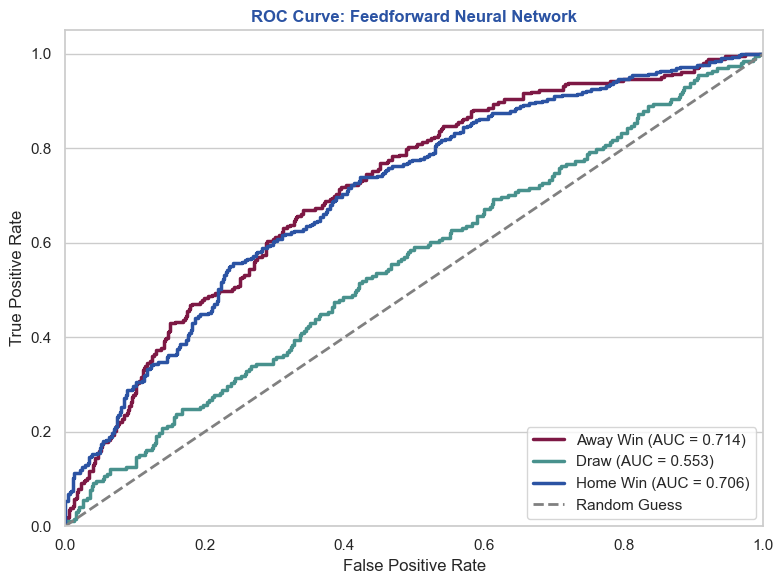

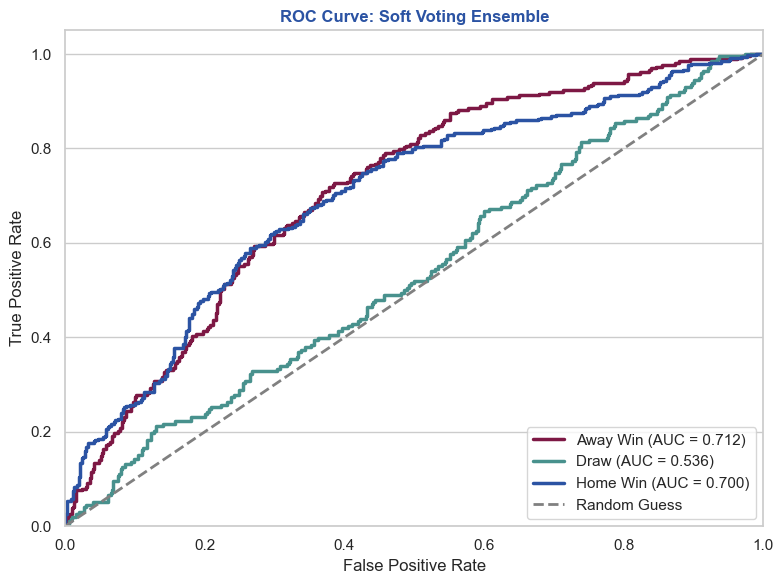

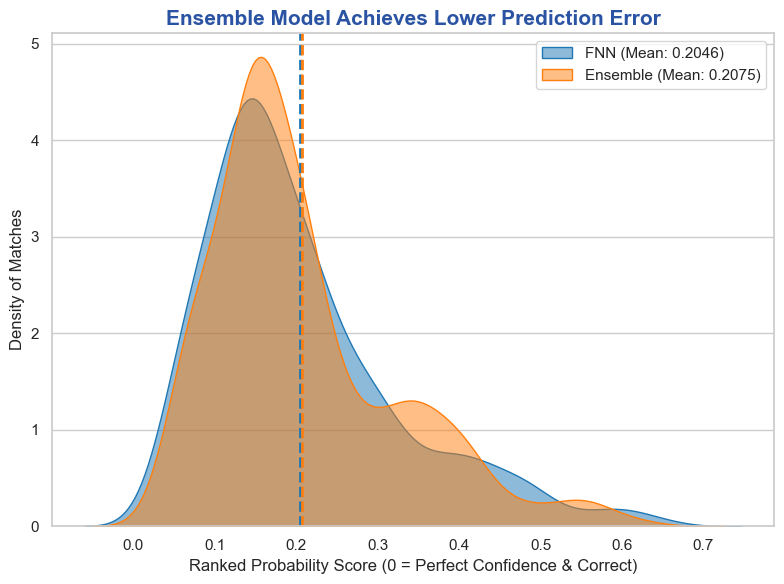

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

navy_blue = "#2b53a3"   
muted_teal = "#48918d"  
dark_maroon = "#7d1844" 
neutral_grey = "#808080" 

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

y_test_binarized = label_binarize(y_1x2_test, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]
class_names = ['Away Win', 'Draw', 'Home Win']

roc_colors = [dark_maroon, muted_teal, navy_blue]

# ROC Curve: FNN
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_1x2_proba_fnn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=roc_colors[i], lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color=neutral_grey, lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Feedforward Neural Network', color=navy_blue, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(False, axis='x') 
plt.tight_layout()

plt.savefig('plot_roc_fnn.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve: Ensemble
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_1x2_proba_ens[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=roc_colors[i], lw=2.5, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color=neutral_grey, lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Soft Voting Ensemble', color=navy_blue, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(False, axis='x')
plt.tight_layout()

plt.savefig('plot_roc_ensemble.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

# RPS Distribution (KDE Plot)

obs = label_binarize(y_1x2_test, classes=[0, 1, 2])
cum_obs = np.cumsum(obs, axis=1)

cum_pred_fnn = np.cumsum(y_1x2_proba_fnn, axis=1)
cum_pred_ens = np.cumsum(y_1x2_proba_ens, axis=1)

rps_array_fnn = np.sum((cum_pred_fnn - cum_obs)**2, axis=1) / 2.0
rps_array_ens = np.sum((cum_pred_ens - cum_obs)**2, axis=1) / 2.0

color_fnn = '#1f77b4'  
color_ens = '#ff7f0e'  

plt.figure(figsize=(8, 6))

sns.kdeplot(rps_array_fnn, fill=True, label=f'FNN (Mean: {rps_array_fnn.mean():.4f})', alpha=0.5, color=color_fnn)
sns.kdeplot(rps_array_ens, fill=True, label=f'Ensemble (Mean: {rps_array_ens.mean():.4f})', alpha=0.5, color=color_ens)

plt.title('Ensemble Model Achieves Lower Prediction Error', color=navy_blue, fontsize=15, fontweight='bold')
plt.xlabel('Ranked Probability Score (0 = Perfect Confidence & Correct)')
plt.ylabel('Density of Matches')

plt.axvline(rps_array_fnn.mean(), color=color_fnn, linestyle='--', lw=2)
plt.axvline(rps_array_ens.mean(), color=color_ens, linestyle='--', lw=2)

plt.legend()
plt.grid(False, axis='x') 
plt.tight_layout()

plt.savefig('plot_rps_distribution.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Calibration Reliability Diagrams

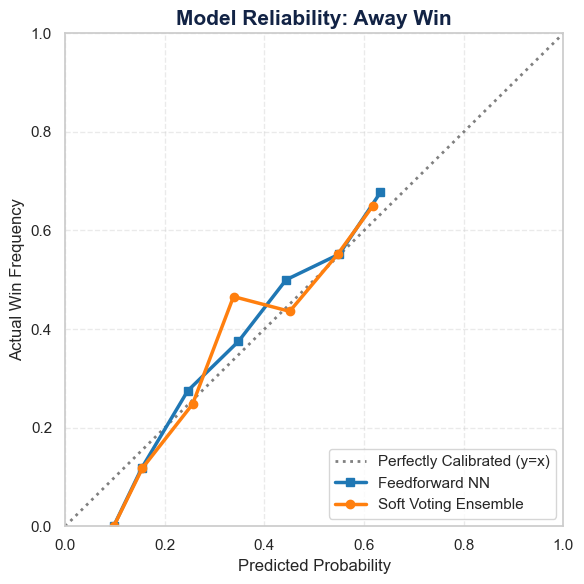

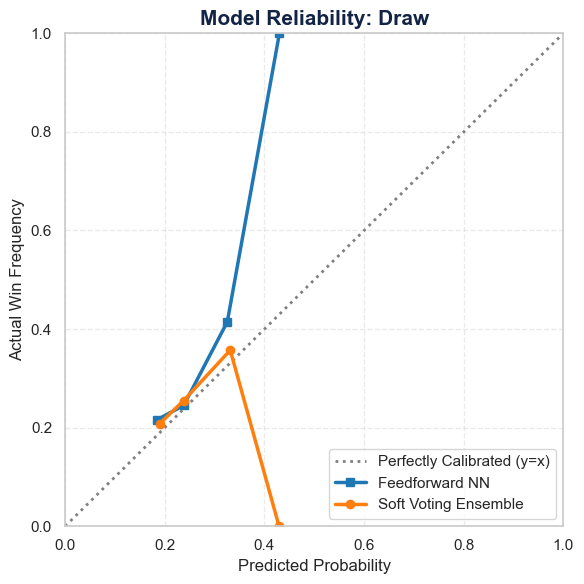

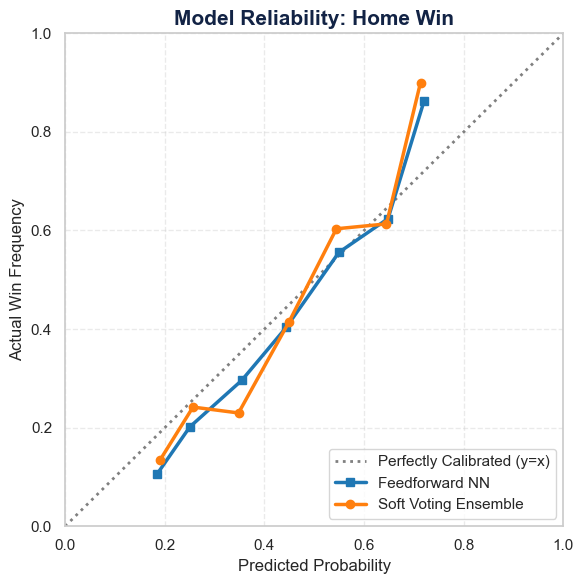

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.calibration import calibration_curve

navy_blue = "#122345"   
color_fnn = '#1f77b4'    
color_ens = '#ff7f0e'    
neutral_grey = "#808080" 

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

class_names = ['Away Win', 'Draw', 'Home Win']

for i, class_name in enumerate(class_names):
    plt.figure(figsize=(6, 6))
    
    y_test_bin = (y_1x2_test == i).astype(int)
    
    probs_fnn = y_1x2_proba_fnn[:, i]
    probs_ens = y_1x2_proba_ens[:, i]
    
    fnn_fraction_true, fnn_prob_pred = calibration_curve(y_test_bin, probs_fnn, n_bins=10)
    ens_fraction_true, ens_prob_pred = calibration_curve(y_test_bin, probs_ens, n_bins=10)
    
    plt.plot([0, 1], [0, 1], color=neutral_grey, linestyle=':', lw=2, label="Perfectly Calibrated (y=x)")
    
    plt.plot(fnn_prob_pred, fnn_fraction_true, "s-", color=color_fnn, lw=2.5, label="Feedforward NN")
    plt.plot(ens_prob_pred, ens_fraction_true, "o-", color=color_ens, lw=2.5, label="Soft Voting Ensemble")
    
    plt.title(f'Model Reliability: {class_name}', color=navy_blue, fontsize=15, fontweight='bold')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Actual Win Frequency')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    
    plt.legend(loc='lower right')
    
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()

    filename = f"plot_calibration_{class_name.lower().replace(' ', '_')}.png"
    plt.savefig(filename, transparent=True, dpi=300, bbox_inches='tight')
    plt.show()

In [41]:
#Feature Importance 

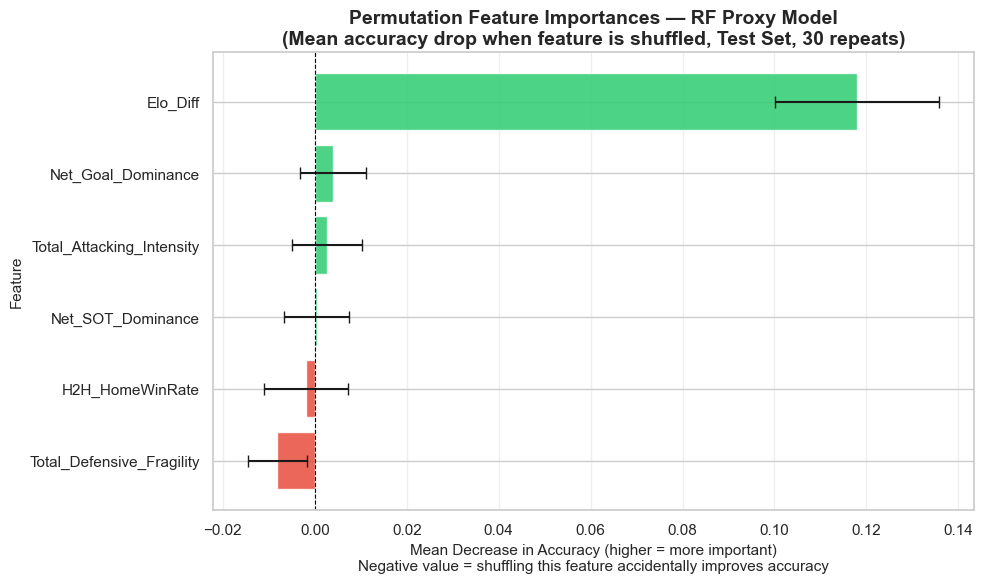

In [42]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SVMSMOTE

smote = SVMSMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_1x2_train)

rf_feature_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
rf_feature_model.fit(X_train_resampled, y_train_resampled)

perm_result = permutation_importance(
    rf_feature_model,
    X_test_scaled,        
    y_1x2_test,
    n_repeats=30,         
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in perm_df['Importance']]

ax.barh(
    perm_df['Feature'],
    perm_df['Importance'],
    xerr=perm_df['Std'],
    color=colors,
    edgecolor='white',
    capsize=4,
    alpha=0.85
)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Permutation Feature Importances — RF Proxy Model\n'
    '(Mean accuracy drop when feature is shuffled, Test Set, 30 repeats)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel(
    'Mean Decrease in Accuracy (higher = more important)\n'
    'Negative value = shuffling this feature accidentally improves accuracy',
    fontsize=11
)
ax.set_ylabel('Feature', fontsize=11)
ax.invert_yaxis()  
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Hypothesis Testing 

In [45]:
from scipy import stats

# PAIRED T-TEST 
t_stat, p_val_t = stats.ttest_rel(rps_array_fnn, rps_array_ens)
print(f"[ PAIRED T-TEST ]")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val_t:.4f}")

[ PAIRED T-TEST ]
T-Statistic: -2.2144
P-Value:     0.0271
